## 5. SGDClassifier

### 5.1 Packages importeren

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, GridSearchCV, cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)
import numpy as np

from preprocessing import(
    spacy_preprocessor,
    spacy_tokenizer,
)
from helpfuncties import load_dataset

### 5.2 Data inladen 

In [2]:
df = load_dataset()
X = df["Omschrijving"]
y = df["Product"]

### 5.3 Train-Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    random_state=42, stratify=y)

### 5.4 Pipeline + Hyperparameter Tuning

#### 5.4.1 TF-IDF en SGDClassifier Pipeline

In [4]:
tfidf = TfidfVectorizer(
    preprocessor=spacy_preprocessor,
    tokenizer=spacy_tokenizer,
    analyzer="word",
    token_pattern=None,
    ngram_range=(1, 2),
    sublinear_tf=True,
    norm="l2"
)

In [5]:
sgd_pipeline = Pipeline([
    ("tfidf", tfidf),
    ("model", SGDClassifier(
    max_iter=5000,
    n_jobs=-1,
    warm_start=True,
    random_state=42,
    average=True
))
])

#### 5.4.2 RandomizedSearchCV

In [6]:
sgd_params = {
    # TF-IDF tuning
    "tfidf__max_features": [20000, 30000, 50000, None],
    "tfidf__min_df": [1, 2, 3, 5],
    "tfidf__max_df": [0.75, 0.85, 0.95],
    "tfidf__ngram_range": [(1,1), (1,2), (1,3)],

    # SGD tuning
    "model__loss": ["hinge", "log_loss", "modified_huber"],
    "model__alpha": stats.loguniform(1e-8, 1e-2),
    "model__penalty": ["l2"],
    "model__class_weight": ["balanced", None],
}

In [7]:
sgd_random = RandomizedSearchCV(
    estimator=sgd_pipeline,
    param_distributions=sgd_params,
    n_iter=50,
    scoring="f1_weighted",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

sgd_random.fit(X_train, y_train)
best_random = sgd_random.best_params_

print("Beste parameters Random Search:", best_random)

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Beste parameters Random Search: {'model__alpha': np.float64(7.693796998920177e-05), 'model__class_weight': 'balanced', 'model__loss': 'hinge', 'model__penalty': 'l2', 'tfidf__max_df': 0.75, 'tfidf__max_features': 50000, 'tfidf__min_df': 3, 'tfidf__ngram_range': (1, 2)}


#### 5.4.3 GridSearchCV

In [8]:
grid_params = {
"model__alpha": [
    best_random["model__alpha"] * 0.1,
    best_random["model__alpha"] * 0.5,
    best_random["model__alpha"],
    best_random["model__alpha"] * 2,
    best_random["model__alpha"] * 5
]
}
sgd_grid = GridSearchCV(
    estimator=sgd_pipeline,
    param_grid=grid_params,
    scoring="f1_weighted",
    cv=3,
    verbose=1,
    n_jobs=-1
)

sgd_grid.fit(X_train, y_train)
sgd_best = sgd_grid.best_estimator_

Fitting 3 folds for each of 5 candidates, totalling 15 fits


#### 5.4.4 Cross Validation

In [9]:
cv_scores = cross_val_score(
    sgd_best, X_train, y_train, cv=5, scoring="f1_weighted"
)

print("CV F1-score:", cv_scores.mean())
print("Scores per fold:", cv_scores)

CV F1-score: 0.8585900931637775
Scores per fold: [0.86352432 0.86864129 0.84661975 0.85659871 0.8575664 ]


### 5.5 Evaluatie Modelprestaties

In [ ]:
y_pred = sgd_best.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy Testset: {acc:.3f}")
print(f"F1-score Testset: {f1:.3f}")
print("\nClassification Report SGD Classifier:")
print(classification_report(y_test, y_pred))

Accuracy Testset: 0.860
F1-score Testset: 0.858

Classification Report SDG Classifier (spaCy preprocessing):
                    precision    recall  f1-score   support

      Bankrekening       0.90      0.85      0.87       446
Consumentenkrediet       0.79      0.59      0.67       284
        Creditcard       0.83      0.85      0.84       564
         Hypotheek       0.91      0.95      0.93       994
           Incasso       0.84      0.88      0.86      1223
Kredietregistratie       0.85      0.83      0.84       934

          accuracy                           0.86      4445
         macro avg       0.85      0.83      0.84      4445
      weighted avg       0.86      0.86      0.86      4445



[[ 378    2   32   14   13    7]
 [   5  168   17   24   49   21]
 [  16    7  481    4   33   23]
 [  13    4    4  949   11   13]
 [   7   15   23   35 1075   68]
 [   2   18   21   18  104  771]]


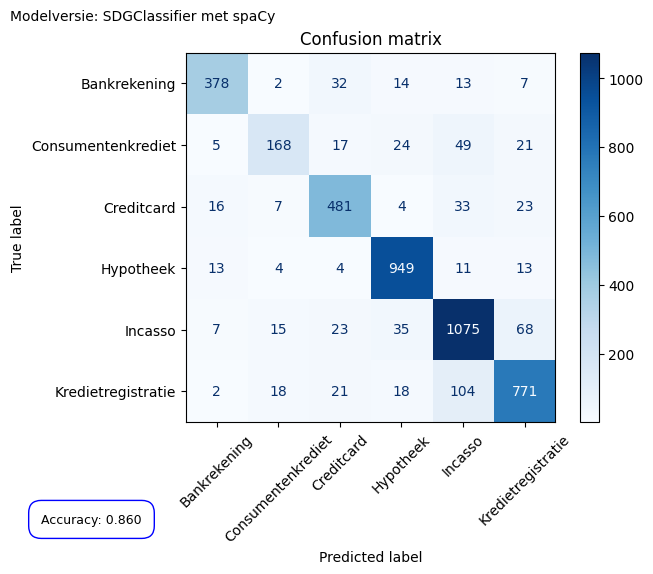

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap='Blues'
)
plt.xticks(rotation=45)
plt.title('Confusion matrix')
plt.suptitle("Modelversie: SGD Classifier", fontsize=10, x=0.1, y=0.97) # ! naam aanpassen per modelversie
plt.figtext(0.02, -0.1, f"Accuracy: {acc:.3f}", ha='center', fontsize=9, color='black', bbox=dict(facecolor='none', edgecolor='blue', boxstyle='round,pad=1'))
plt.savefig("afbeeldingen/confusion_matrix_SGDClassifier.png", dpi=300, bbox_inches='tight') # ! naam aanpassen per modelversie
plt.show()